In [ ]:
# Copyright 2025 Bytedance Ltd. and/or its affiliates.
# SPDX-License-Identifier: Apache-2.0

In [3]:
import os
import torch
import torch_npu
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["GOTO_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
%load_ext autoreload
%autoreload 2
# %pip install -U ipywidgets # 不用每次都跑

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from copy import deepcopy
from typing import (
    Any,
    AsyncIterable,
    Callable,
    Dict,
    Generator,
    List,
    NamedTuple,
    Optional,
    Tuple,
    Union,
)
import requests
from io import BytesIO

from PIL import Image
from accelerate import infer_auto_device_map, load_checkpoint_and_dispatch, init_empty_weights

from data.transforms import ImageTransform
from data.data_utils import pil_img2rgb, add_special_tokens
from modeling.bagel import (
    BagelConfig, Bagel, Qwen2Config, Qwen2ForCausalLM, SiglipVisionConfig, SiglipVisionModel
)
from modeling.qwen2 import Qwen2Tokenizer
from modeling.bagel.qwen2_navit import NaiveCache
from modeling.autoencoder import load_ae
from safetensors.torch import load_file

## Model Initialization

In [5]:
model_path = "/home/ma-user/work/models/bagel_base/BAGEL-7B-MoT"  # Download from https://huggingface.co/ByteDance-Seed/BAGEL-7B-MoT

# LLM config preparing
llm_config = Qwen2Config.from_json_file(os.path.join(model_path, "llm_config.json"))
llm_config.qk_norm = True
llm_config.tie_word_embeddings = False
llm_config.layer_module = "Qwen2MoTDecoderLayer"

# ViT config preparing
vit_config = SiglipVisionConfig.from_json_file(os.path.join(model_path, "vit_config.json"))
vit_config.rope = False
vit_config.num_hidden_layers = vit_config.num_hidden_layers - 1

# VAE loading
vae_model, vae_config = load_ae(local_path=os.path.join(model_path, "ae.safetensors"))

# ⭐ 关键：把 VAE 放到 NPU
vae_model = vae_model.to(device="npu:0", dtype=torch.bfloat16).eval()


# Bagel config preparing
config = BagelConfig(
    visual_gen=True,
    visual_und=True,
    llm_config=llm_config, 
    vit_config=vit_config,
    vae_config=vae_config,
    vit_max_num_patch_per_side=70,
    connector_act='gelu_pytorch_tanh',
    latent_patch_size=2,
    max_latent_size=64,
)

In [6]:
import time
from accelerate import init_empty_weights

t0 = time.time()
with init_empty_weights():
    language_model = Qwen2ForCausalLM(llm_config)
    vit_model      = SiglipVisionModel(vit_config)
    model          = Bagel(language_model, vit_model, config)

# 这里建议 meta=True（跟 meta 构建一致，避免真实分配/初始化）
model.vit_model.vision_model.embeddings.convert_conv2d_to_linear(vit_config, meta=True)
print("build (meta, no init):", time.time() - t0)

# Tokenizer Preparing（你原样保留）
tokenizer = Qwen2Tokenizer.from_pretrained(model_path)
tokenizer, new_token_ids, _ = add_special_tokens(tokenizer)

# Image Transform Preparing（你原样保留）
vae_transform = ImageTransform(1024, 512, 16)
vit_transform = ImageTransform(980, 224, 14)


build (meta, no init): 2.2638914585113525


## Model Loading and Multi GPU Infernece Preparing

In [7]:
from safetensors.torch import load_file

# 选择单卡
device = "npu:0"
dtype = torch.bfloat16

ckpt_path = os.path.join(model_path, "ema.safetensors")
assert os.path.exists(ckpt_path), f"checkpoint not found: {ckpt_path}"

# 1) 先把权重读到 CPU（避免直接读到 NPU 时出奇怪问题）
state = load_file(ckpt_path, device="cpu")

# 2) 灌权重到模型
# 说明：如果 strict=True 报错（keys 不一致），改成 strict=False，并打印 missing/unexpected
# missing, unexpected = model.load_state_dict(state, strict=False)尝试减少时间
missing, unexpected = model.load_state_dict(state, strict=False, assign=True)
print(f"load_state_dict done. missing={len(missing)} unexpected={len(unexpected)}")
if len(missing) > 0:
    print("missing example:", missing[:20])
if len(unexpected) > 0:
    print("unexpected example:", unexpected[:20])

# 3) 整体搬到 NPU
model = model.to(device=device, dtype=dtype).eval()

# 4) 快速 sanity check
p = next(model.parameters())
print("Model loaded. param device =", p.device, "dtype =", p.dtype)

load_state_dict done. missing=0 unexpected=0
Model loaded. param device = npu:0 dtype = torch.bfloat16


## Inferencer Preparing 

In [8]:
from inferencer import InterleaveInferencer

inferencer = InterleaveInferencer(
    model=model, 
    vae_model=vae_model, 
    tokenizer=tokenizer, 
    vae_transform=vae_transform, 
    vit_transform=vit_transform, 
    new_token_ids=new_token_ids
)

In [ ]:
# import random
# import numpy as np
# seed = 42
# random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)

# if hasattr(torch, "npu") and torch.npu.is_available():
#     torch.npu.manual_seed(seed)

In [9]:
# 随机seed
import random
import numpy as np
import torch
import time

# 用时间 + 随机源生成一个 seed
seed = int(time.time() * 1000) % (2**31 - 1)

print(f"[Seed] Using random seed = {seed}")

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if hasattr(torch, "npu") and torch.npu.is_available():
    torch.npu.manual_seed(seed)


[Seed] Using random seed = 80694675


**About Inference Hyperparameters:**
- **`cfg_text_scale`:** Controls how strongly the model follows the text prompt. `1.0` disables text guidance. Typical range: `4.0–8.0`.
- **`cfg_image_scale`:** Controls how much the model preserves input image details. `1.0` disables image guidance. Typical range: `1.0–2.0`.
- **`cfg_interval`:** Fraction of denoising steps where CFG is applied. Later steps can skip CFG to reduce computation. Typical: `[0.4, 1.0]`.
- **`timestep_shift`:** Shifts the distribution of denoising steps. Higher values allocate more steps at the start (affects layout); lower values allocate more at the end (improves details).
- **`num_timesteps`:** Total denoising steps. Typical: `50`.
- **`cfg_renorm_min`:** Minimum value for CFG-Renorm. `1.0` disables renorm. Typical: `0`.
- **`cfg_renorm_type`:** CFG-Renorm method:  
  - `global`: Normalize over all tokens and channels (default for T2I).
  - `channel`: Normalize across channels for each token.
  - `text_channel`: Like `channel`, but only applies to text condition (good for editing, may cause blur).
- **If edited images appear blurry, try `global` CFG-Renorm, decrease `cfg_renorm_min` or decrease `cfg_scale`.**


## Image Generation

In [10]:
inference_hyper=dict(
    cfg_text_scale=4.0,
    cfg_img_scale=1.0,
    cfg_interval=[0.4, 1.0],
    timestep_shift=3.0,
    num_timesteps=20, # default 50
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
    image_shapes=(1024, 576),
)

100%|██████████| 19/19 [00:08<00:00,  2.21it/s]


inferencer total: 20.015 s
get image obj: 0.000125 s <class 'PIL.Image.Image'> (576, 1024)


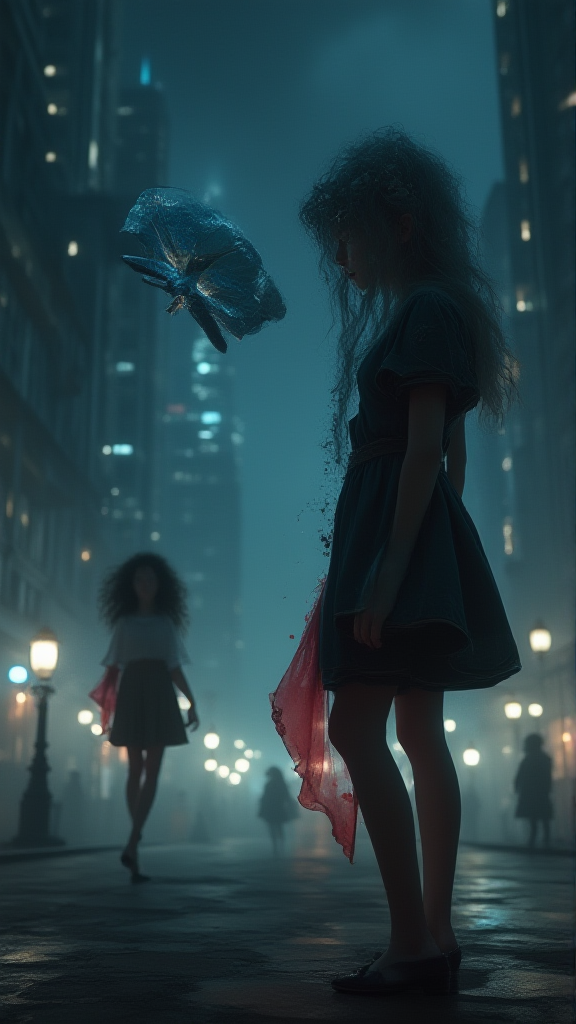

display(): 0.116 s


In [11]:
prompt = """
girl
"""

# print(prompt)
# print('-' * 10)
from IPython.display import display

t0 = time.time()
output_dict = inferencer(text=prompt, **inference_hyper)
t1 = time.time()
print("inferencer total:", round(t1 - t0, 3), "s")

t0 = time.time()
img = output_dict["image"]
t1 = time.time()
print("get image obj:", round(t1 - t0, 6), "s", type(img), img.size)

t0 = time.time()
display(img)
t1 = time.time()
print("display():", round(t1 - t0, 3), "s")

## Image Generation with Think

In [12]:
inference_hyper=dict(
    max_think_token_n=1000,
    do_sample=False,
    # text_temperature=0.3,
    cfg_text_scale=4.0,
    cfg_img_scale=1.0,
    cfg_interval=[0.4, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
)

a car made of small cars
----------


100%|██████████| 49/49 [00:35<00:00,  1.37it/s]


<think>
The model should generate an image of a large car composed entirely of smaller cars arranged in a cohesive structure, demonstrating a creative and unconventional design.
Here’s the full, detailed prompt: A massive, intricately designed car composed entirely of smaller cars arranged in a cohesive and artistic structure, showcasing a creative and unconventional design. The smaller cars are tightly packed and organized in a visually striking pattern, with varying shapes, colors, and models creating a dynamic and textured surface. The scene is set in a spacious, well-lit studio with neutral tones, emphasizing the car's unique composition. The lighting is soft and diffused, highlighting the details of the smaller cars while maintaining a clean and modern aesthetic. The overall atmosphere is futuristic and imaginative, with a focus on the ingenuity of the design.
</think>


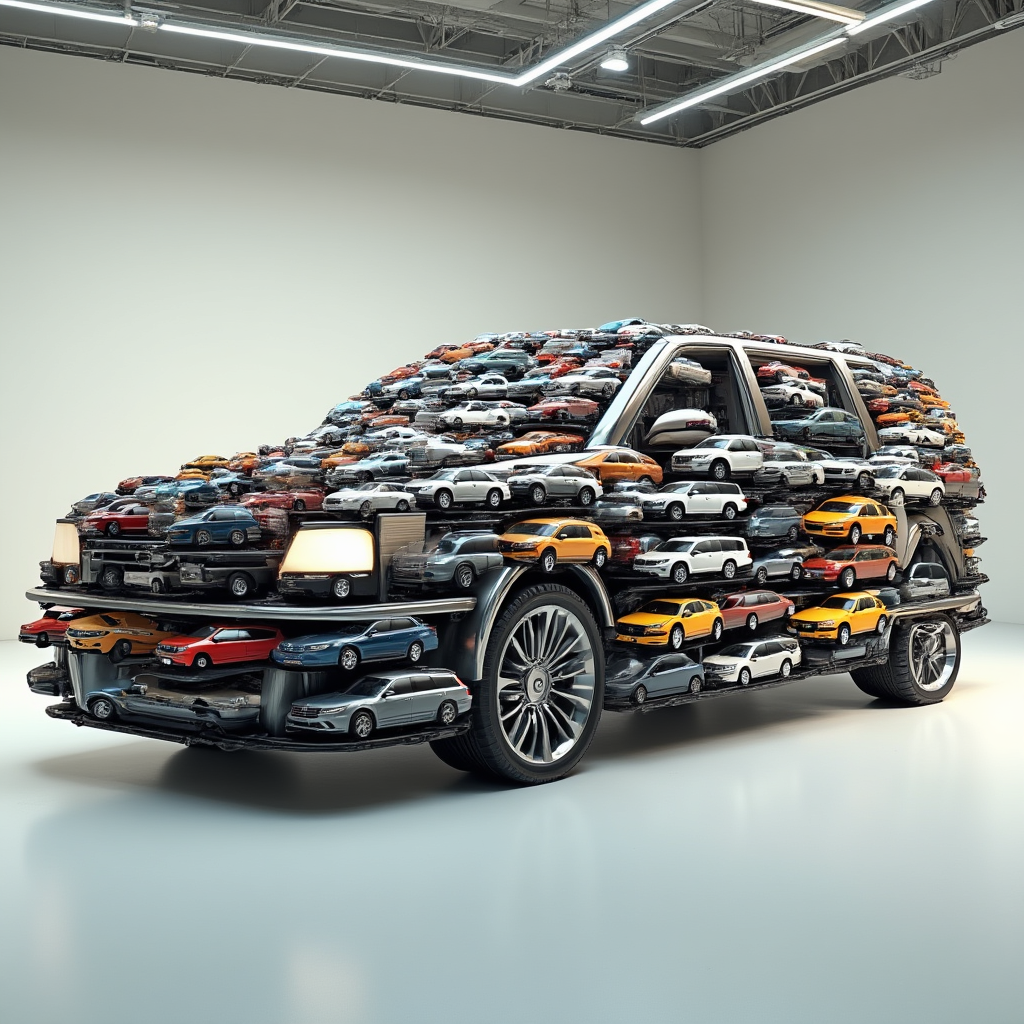

In [15]:
prompt = 'a car made of small cars'

print(prompt)
print('-' * 10)
output_dict = inferencer(text=prompt, think=True, **inference_hyper)
print(output_dict['text'])
display(output_dict['image'])

## Editing

In [16]:
inference_hyper=dict(
    cfg_text_scale=4.0,
    cfg_img_scale=2.0,
    cfg_interval=[0.0, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="text_channel",
)

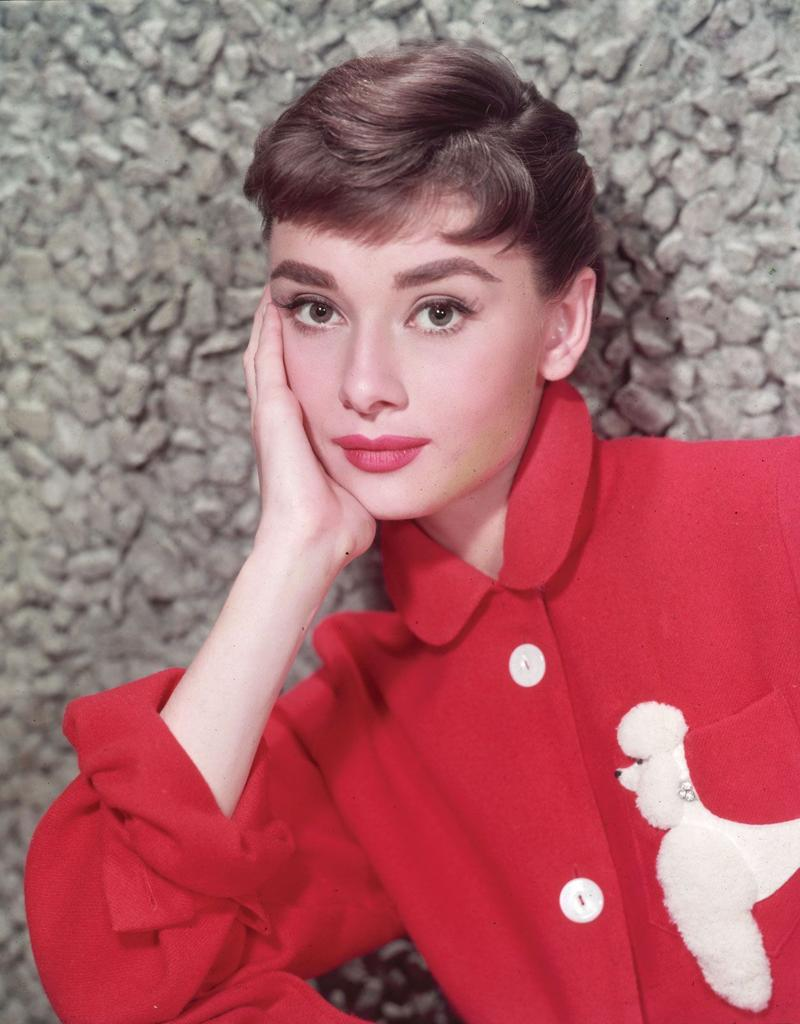

She boards a modern subway, quietly reading a folded newspaper, wearing the same clothes.
----------


RuntimeError: Input type (float) and bias type (c10::BFloat16) should be the same

In [18]:
image = Image.open('test_images/women.jpg')
prompt = 'She boards a modern subway, quietly reading a folded newspaper, wearing the same clothes.'

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, **inference_hyper)
display(output_dict['image'])

## Edit with Think

In [ ]:
inference_hyper=dict(
    max_think_token_n=1000,
    do_sample=False,
    # text_temperature=0.3,
    cfg_text_scale=4.0,
    cfg_img_scale=2.0,
    cfg_interval=[0.0, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="text_channel",
)

In [ ]:
image = Image.open('test_images/octupusy.jpg')
prompt = 'Could you display the sculpture that takes after this design?'

display(image)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, think=True, **inference_hyper)
print(output_dict['text'])
display(output_dict['image'])

## Understanding

In [ ]:
inference_hyper=dict(
    max_think_token_n=1000,
    do_sample=False,
    # text_temperature=0.3,
)

In [ ]:
image = Image.open('test_images/meme.jpg')
prompt = "Can someone explain what’s funny about this meme??"

display(image)
print(prompt)
print('-'*10)
output_dict = inferencer(image=image, text=prompt, understanding_output=True, **inference_hyper)
print(output_dict['text'])

## TaylorSeer Support for Inference Acceleration

In [ ]:
# Enable TaylorSeer (https://arxiv.org/abs/2503.06923) by setting enable_taylorseer=True in inference_hyper
# This feature is supported for tasks that involve image output, including image generation, image generation with think, editing, and edit with think.

# Below is an example of image generation with TaylorSeer enabled.
inference_hyper=dict(
    cfg_text_scale=4.0,
    cfg_img_scale=1.0,
    cfg_interval=[0.4, 1.0],
    timestep_shift=3.0,
    num_timesteps=50,
    cfg_renorm_min=0.0,
    cfg_renorm_type="global",
    enable_taylorseer=True,  # Enable TaylorSeer
)

In [ ]:
prompt = "A female cosplayer portraying an ethereal fairy or elf, wearing a flowing dress made of delicate fabrics in soft, mystical colors like emerald green and silver. She has pointed ears, a gentle, enchanting expression, and her outfit is adorned with sparkling jewels and intricate patterns. The background is a magical forest with glowing plants, mystical creatures, and a serene atmosphere."

print(prompt)
print('-' * 10)
output_dict = inferencer(text=prompt, **inference_hyper)
display(output_dict['image'])